<a href="https://colab.research.google.com/github/hamsa-nk/logistics-data-analysis/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_delivery_logistics.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (25000, 17)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost,delay_hours,delay_status
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206,0,On Time
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700,-1,On Time
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700,-6,On Time
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700,-2,On Time
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600,-7,On Time


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  int64  
 10  expected_time_hours  25000 non-null  int64  
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
 15  delay_hours          25000 non-null 

,delivery_id,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost,delay_hours
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,6.248040,13.107680,3.666000,864.944579,-6.859640
std,7212.732314,86.409745,14.368663,3.140935,7.559024,1.149964,435.712593,8.069482
min,250.990000,3.600000,0.670000,0.000000,2.000000,1.000000,95.667400,-24.000000
25%,6250.750000,75.900000,12.680000,4.000000,8.000000,3.000000,490.800000,-14.000000
50%,12500.500000,151.000000,25.145000,6.000000,8.000000,4.000000,867.535000,-6.000000
75%,18750.250000,224.900000,37.660000,8.000000,16.000000,5.000000,1237.910000,0.000000
max,24750.010000,297.100000,49.520000,19.000000,24.000000,5.000000,1632.720600,12.000000


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 25000
Number of columns: 17


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Delivery IDs:")
print(df["delivery_id"].duplicated().sum())

Missing Values:
delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
delay_hours            0
delay_status           0
dtype: int64

Duplicate Rows:
0

Duplicate Delivery IDs:
498


In [6]:
numerical_columns = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost",
    "delay_hours"
]

df[numerical_columns].describe()

,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost,delay_hours
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,150.390436,25.145898,6.248040,13.107680,3.666000,864.944579,-6.859640
std,86.409745,14.368663,3.140935,7.559024,1.149964,435.712593,8.069482
min,3.600000,0.670000,0.000000,2.000000,1.000000,95.667400,-24.000000
25%,75.900000,12.680000,4.000000,8.000000,3.000000,490.800000,-14.000000
50%,151.000000,25.145000,6.000000,8.000000,4.000000,867.535000,-6.000000
75%,224.900000,37.660000,8.000000,16.000000,5.000000,1237.910000,0.000000
max,297.100000,49.520000,19.000000,24.000000,5.000000,1632.720600,12.000000


In [7]:
df[numerical_columns].median()

,0
distance_km,151.000
package_weight_kg,25.145
delivery_time_hours,6.000
expected_time_hours,8.000
delivery_rating,4.000
delivery_cost,867.535
delay_hours,-6.000


In [8]:
def outlier_analysis(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

In [9]:
weight_outliers = outlier_analysis("package_weight_kg")
weight_outliers[
    ["delivery_id", "package_type", "package_weight_kg", "delivery_cost"]
].head(10)


Column: package_weight_kg
Q1: 12.68
Q3: 37.66
IQR: 24.98
Lower Bound: -24.79
Upper Bound: 75.13
Number of Outliers: 0


,delivery_id,package_type,package_weight_kg,delivery_cost


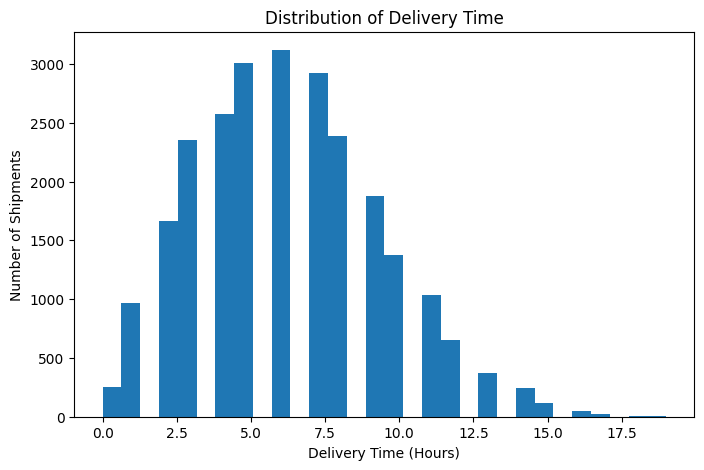

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["delivery_time_hours"], bins=30)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Hours)")
plt.ylabel("Number of Shipments")

plt.show()

In [12]:
print("Mean delivery time:",
      df["delivery_time_hours"].mean())

print("Median delivery time:",
      df["delivery_time_hours"].median())

print("Minimum delivery time:",
      df["delivery_time_hours"].min())

print("Maximum delivery time:",
      df["delivery_time_hours"].max())

Mean delivery time: 6.24804
Median delivery time: 6.0
Minimum delivery time: 0
Maximum delivery time: 19


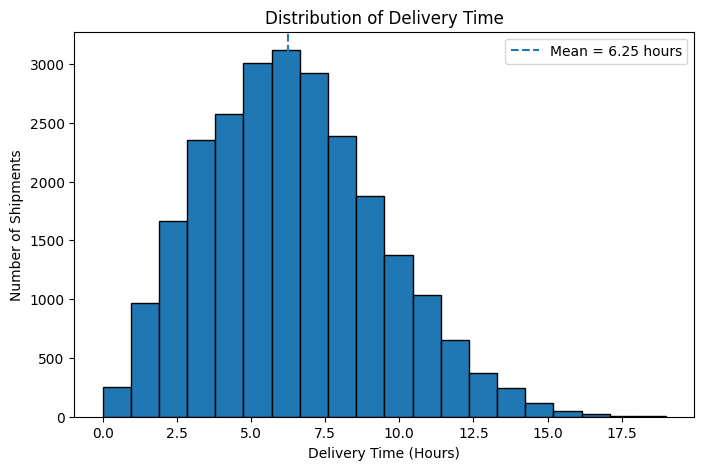

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["delivery_time_hours"], bins=20, edgecolor="black")

plt.axvline(
    df["delivery_time_hours"].mean(),
    linestyle="--",
    label=f"Mean = {df['delivery_time_hours'].mean():.2f} hours"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Hours)")
plt.ylabel("Number of Shipments")
plt.legend()

plt.show()

In [14]:
print(df["delivery_status"].value_counts())

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64


In [15]:
print(df["delivery_status"].value_counts(normalize=True) * 100)

delivery_status
delivered    73.324
delayed      21.364
failed        5.312
Name: proportion, dtype: float64


In [16]:
print(df["delayed"].value_counts())

delayed
no     18331
yes     6669
Name: count, dtype: int64


In [17]:
print(df["delayed"].value_counts(normalize=True) * 100)

delayed
no     73.324
yes    26.676
Name: proportion, dtype: float64


In [18]:
status_counts = df["delivery_status"].value_counts()

print(status_counts)

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64


In [19]:
pd.crosstab(
    df["delivery_status"],
    df["delayed"],
    margins=True
)

delayed,no,yes,All
delivery_status,,,
delayed,0,5341,5341
delivered,18331,0,18331
failed,0,1328,1328
All,18331,6669,25000


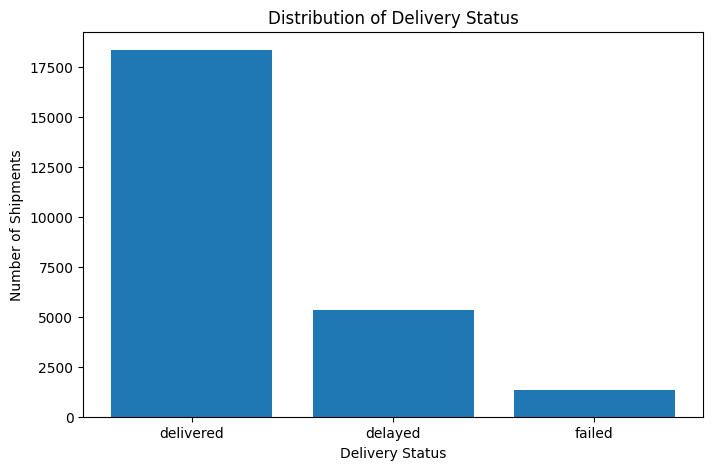

In [20]:
status_counts = df["delivery_status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(status_counts.index, status_counts.values)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")

plt.show()

In [22]:
status_percent = (
    df["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percent)

delivery_status
delivered    73.32
delayed      21.36
failed        5.31
Name: proportion, dtype: float64


In [23]:
region_performance = pd.crosstab(
    df["region"],
    df["delivery_status"],
    normalize="index"
) * 100

print(region_performance.round(2))

delivery_status  delayed  delivered  failed
region                                     
central            21.60      72.75    5.65
east               20.82      74.20    4.98
north              21.80      73.43    4.77
south              21.28      73.22    5.51
west               21.32      73.05    5.63


In [24]:
region_counts = pd.crosstab(
    df["region"],
    df["delivery_status"]
)

print(region_counts)

delivery_status  delayed  delivered  failed
region                                     
central             1093       3681     286
east                1024       3650     245
north               1079       3634     236
south               1059       3644     274
west                1086       3722     287


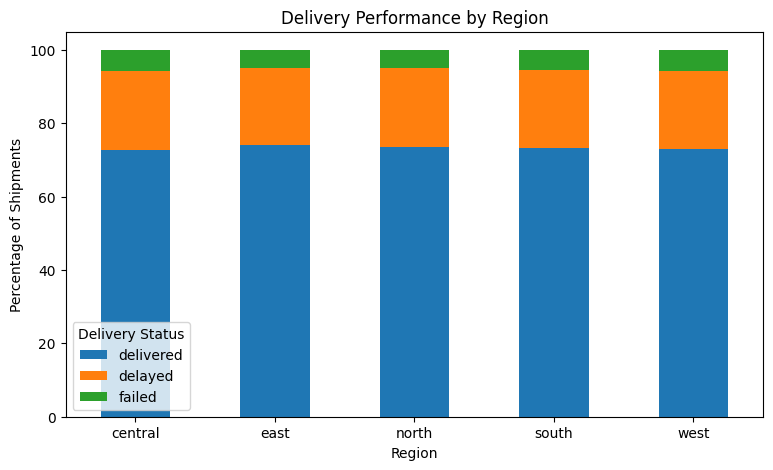

In [26]:
region_performance = pd.crosstab(
    df["region"],
    df["delivery_status"],
    normalize="index"
) * 100

region_performance = region_performance[
    ["delivered", "delayed", "failed"]
]

region_performance.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Delivery Performance by Region")
plt.xlabel("Region")
plt.ylabel("Percentage of Shipments")
plt.legend(title="Delivery Status")

plt.xticks(rotation=0)
plt.show()

In [25]:
correlation = df["distance_km"].corr(
    df["delivery_time_hours"]
)

print("Correlation:", round(correlation, 3))

Correlation: 0.686


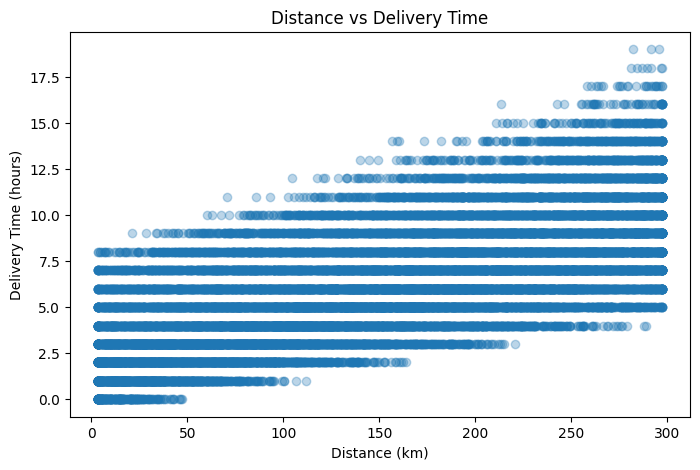

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["delivery_time_hours"],
    alpha=0.3
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (hours)")

plt.show()

In [28]:
df["distance_km"].corr(df["delivery_cost"])

np.float64(0.9907716907515611)

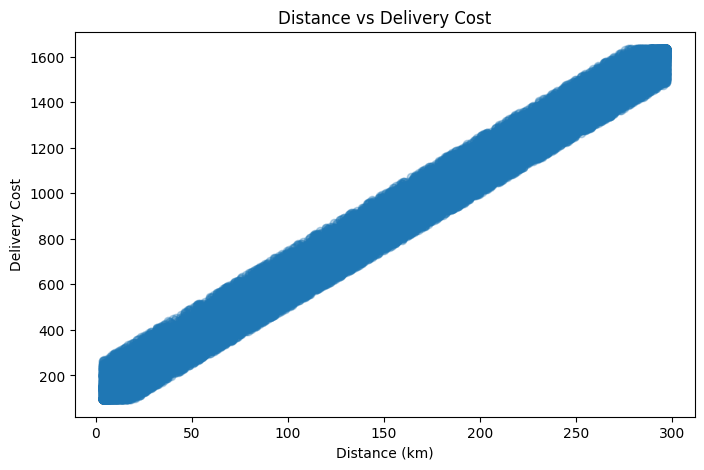

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["delivery_cost"],
    alpha=0.3
)

plt.title("Distance vs Delivery Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")

plt.show()

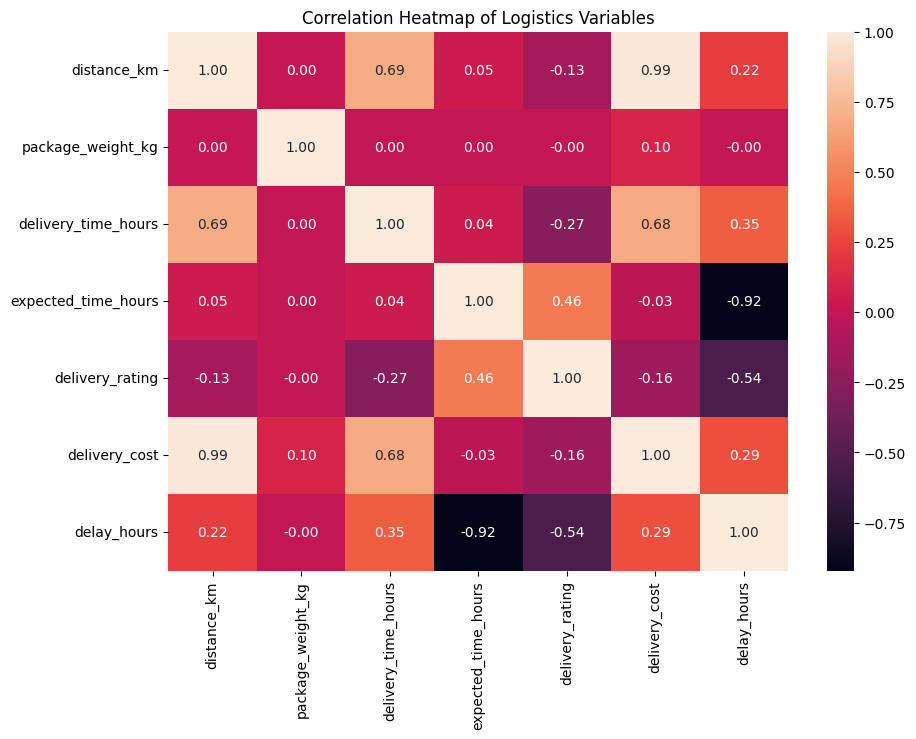

In [30]:
numerical_columns = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost",
    "delay_hours"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Logistics Variables")
plt.show()